<a href="https://colab.research.google.com/github/varaiitj2527/PRMLProject/blob/main/Model/Bayesian_Models/Gaussian_Naive_Bayes_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 143, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 143 (delta 43), reused 21 (delta 2), pack-reused 18 (from 2)
Receiving objects: 100% (143/143), 207.94 MiB | 10.68 MiB/s, done.
Resolving deltas: 100% (43/43), done.
Updating files: 100% (45/45), done.
Filtering content: 100% (14/14), 1.29 GiB | 67.03 MiB/s, done.
Encountered 2 file(s) that should have been pointers, but weren't:
	PreProcessedData/quicknet_test.pkl
	PreProcessedData/quicknet_train.pkl
/content/PRMLProject


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle

In [3]:
def unpickle(filename) :

  with open(filename, 'rb') as file :
      data = pickle.load(file, encoding='bytes')

  return data

In [4]:
train_RawData = unpickle('PreProcessedData/RawPixels_train.pkl')
test_RawData = unpickle('PreProcessedData/RawPixels_test.pkl')

train_labels = unpickle('PreProcessedData/Labels_train.pkl')
test_labels = unpickle('PreProcessedData/Labels_test.pkl')

train_PcaData = unpickle('PreProcessedData/TrainFeaturesPCA.pkl')
test_PcaData = unpickle('PreProcessedData/TestFeaturesPCA.pkl')

train_HoGData = unpickle('PreProcessedData/TrainFeaturesHoG.pkl')
test_HoGData = unpickle('PreProcessedData/TestFeaturesHoG.pkl')

train_Pca_HoGData = unpickle('PreProcessedData/TrainFeaturesPCA_HoG.pkl')
test_Pca_HoGData = unpickle('PreProcessedData/TestFeaturesPCA_HoG.pkl')

train_HoG_PcaData = unpickle('PreProcessedData/TrainFeaturesHoG_PCA.pkl')
test_HoG_PcaData = unpickle('PreProcessedData/TestFeaturesHoG_PCA.pkl')

train_ResnetData = unpickle('PreProcessedData/Resnet_train.pkl')
test_ResnetData = unpickle('PreProcessedData/Resnet_test.pkl')

train_QuicknetData = unpickle('quicknet_train.pkl')
test_QunicknetData = unpickle('quicknet_test.pkl')

In [5]:
X_train = [train_RawData.reshape(-1,3072),train_HoGData,train_PcaData,train_HoG_PcaData,train_Pca_HoGData,train_ResnetData,train_QuicknetData]
y_train = train_labels
X_test = [test_RawData.reshape(-1,3072),test_HoGData,test_PcaData,test_HoG_PcaData,test_Pca_HoGData,test_ResnetData,test_QunicknetData]
y_test = test_labels

In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

def GNB(X_train,y_train,X_test,y_test) :

    clf = GaussianNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return y_pred

def CM(y_test,y_pred,name) :

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix for " + name)
    plt.show()

Raw Accuracy : 0.2976


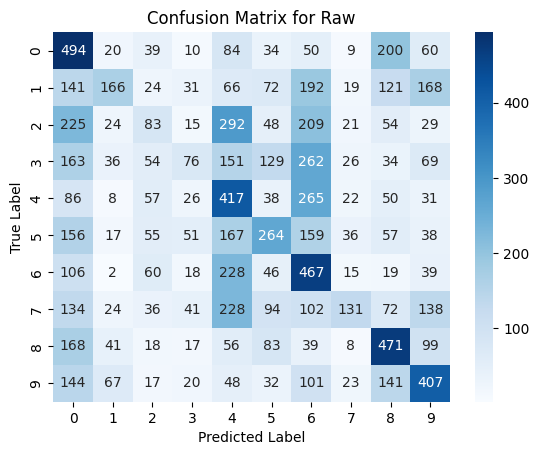

In [10]:
y_raw = GNB(X_train[0],y_train,X_test[0],y_test)
accuracy = accuracy_score(y_test, y_raw)
print("Raw Accuracy :",accuracy)
CM(y_test,y_raw,"Raw")

HoG Accuracy : 0.458


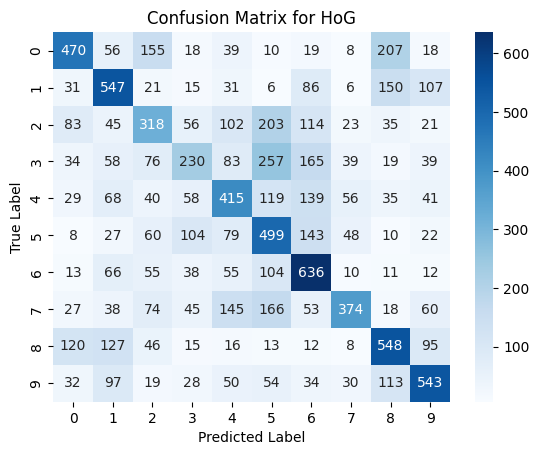

In [12]:
y_HoG = GNB(X_train[1],y_train,X_test[1],y_test)
accuracy = accuracy_score(y_test, y_HoG)
print("HoG Accuracy :",accuracy)
CM(y_test,y_HoG,"HoG")

PCA Accuracy : 0.2894


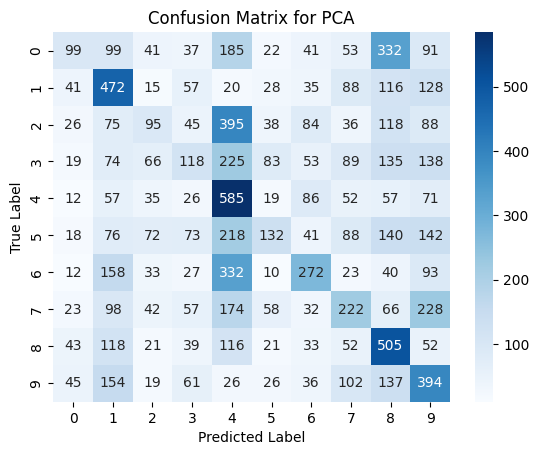

In [14]:
y_Pca = GNB(X_train[2],y_train,X_test[2],y_test)
accuracy = accuracy_score(y_test, y_Pca)
print("PCA Accuracy :",accuracy)
CM(y_test,y_Pca,"PCA")

HoG_PCA Accuracy : 0.4701


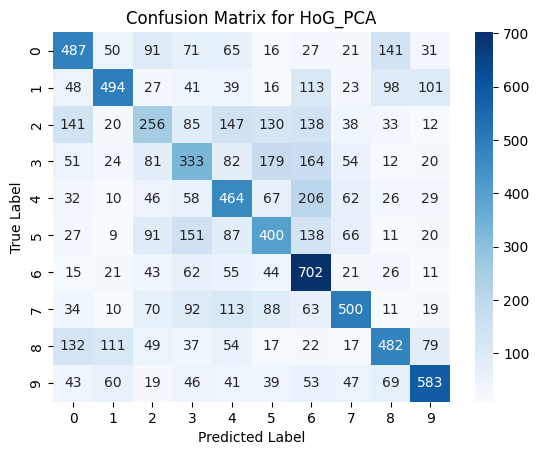

In [15]:
y_HoG_Pca = GNB(X_train[3],y_train,X_test[3],y_test)
accuracy = accuracy_score(y_test, y_HoG_Pca)
print("HoG_PCA Accuracy :",accuracy)
CM(y_test,y_HoG_Pca,"HoG_PCA")

PCA_HoG Accuracy : 0.4309


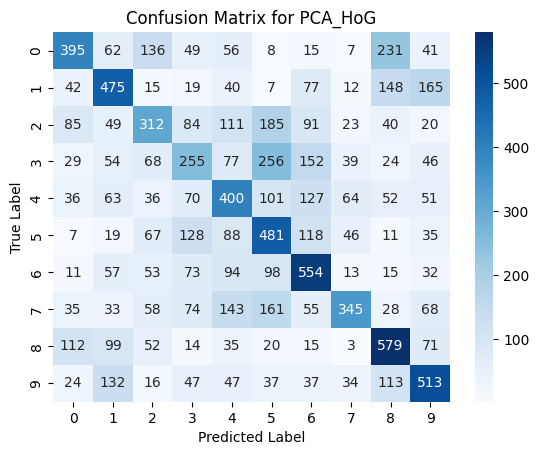

In [16]:
y_Pca_HoG = GNB(X_train[4],y_train,X_test[4],y_test)
accuracy = accuracy_score(y_test, y_Pca_HoG)
print("PCA_HoG Accuracy :",accuracy)
CM(y_test,y_Pca_HoG,"PCA_HoG")

Resnet Accuracy : 0.8025


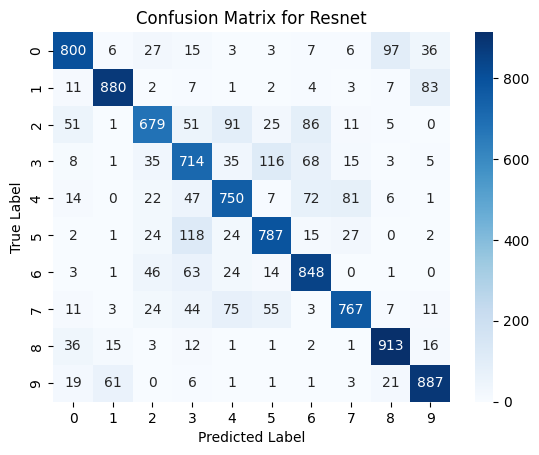

In [17]:
y_Resnet = GNB(X_train[5],y_train,X_test[5],y_test)
accuracy = accuracy_score(y_test, y_Resnet)
print("Resnet Accuracy :",accuracy)
CM(y_test,y_Resnet,"Resnet")

Quicknet Accuracy : 0.6599


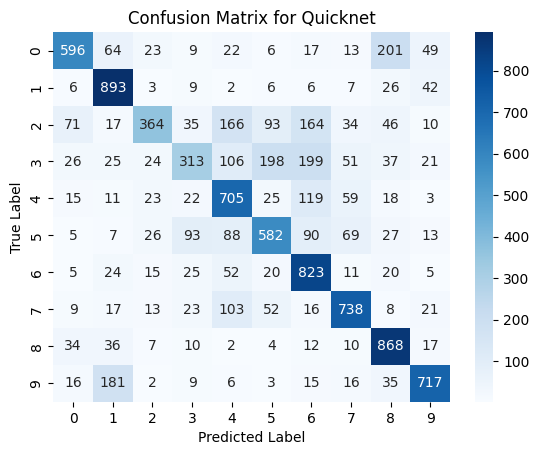

In [18]:
y_Quicknet = GNB(X_train[6],y_train,X_test[6],y_test)
accuracy = accuracy_score(y_test, y_Quicknet)
print("Quicknet Accuracy :",accuracy)
CM(y_test,y_Quicknet,"Quicknet")